## 端到端机器学习项目
---

* 端到端机器学习项目的主要步骤：
    1. 框定问题
        1. 任务目标是什么
        2. 当前的解决方案是什么样的（如果有）
        3. 设计你的系统
    2. 选择性能指标
        * RMSE-均方根误差
        * MAE-平均绝对误差
    3. 检查假设
        * 检查框定问题时所提出的所有假设，可尽早发现问题
    4. 获取数据
    5. 快速浏览数据结构
    6. 创建测试集
    7. 探索和可视化数据以获得见解
    8. 为机器学习算法准备数据
---

### 补充知识点
* 数据流水线
    * 定义：一系列数据处理组件称为数据流水线

In [3]:
# 获取和加载数据的函数
from pathlib import Path # 用面向对象的方式处理路径（跨 Windows/Linux/macOS 更稳），例如拼路径、判断文件是否存在、创建目录等。
import pandas as pd # 读取 CSV 并返回 DataFrame。
import tarfile # 用于打开和解压 .tgz（本质是 tar + gzip）压缩包。
import urllib.request # 标准库的下载工具，用于把 URL 指向的文件下载到本地。

from sympy.abc import alpha


# 定义一个无参数函数，默认把数据放到当前工作目录下的 datasets/ 中。
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz") # 1. 定义压缩包路径
    # 2. 判断本地是否已存在压缩包；不存在就下载
    if not tarball_path.is_file():
        # 创建目录：
        Path("datasets").mkdir(parents=True, exist_ok=True) # parents=True：如果中间目录不存在（例如 datasets/），自动递归创建；exist_ok=True：如果目录已经存在，不报错。
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path) # 下载：从 url 下载文件到本地 tarball_path。
        # 3. 打开压缩包并解压到 datasets 目录
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets") # extractall(path="datasets")：把压缩包里所有内容解压到 datasets/ 目录下。
    return pd.read_csv("datasets/housing/housing.csv")

housing = load_housing_data()

# 5.快速浏览数据结构
1. `DataFrame.head()` # 查看数据的前五行
2. `DataFrame.info()` # 快速描述 DataFrame 的**结构信息**，包括行数、列数、列类型、非空数量、内存占用等。
3. `DataFrame['attribute'].value_counts` # 用于**统计某一列中各取值出现的频数，并按出现次数从高到低排序**返回结果。
4. `DataFrame.describe()` # 用于对 **数值型特征** 进行统计描述
5. `DataFrame.hist()` # 为每个数值属性绘制直方图

In [3]:
# .head() 查看数据的前五行
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
# info() 快速描述 DataFrame 的结构信息，包括行数、列数、列类型、非空数量、内存占用等。
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


---

# 📊 1. `housing_data.info()` 简易笔记

## 1. `info()` 的作用

`DataFrame.info()` 用于**快速查看数据集的整体结构**，主要包括：

* 样本数量（行数）
* 特征数量（列数）
* 每一列的数据类型（dtype）
* 每一列的非空值数量
* 是否存在缺失值
* 数据集的内存占用情况

该方法常用于 **数据读取后的第一步检查（数据体检）**。

---

## 2. 数据集整体信息

```text
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
```

* 数据类型：`pandas.DataFrame`
* 样本数量：**20640 条**
* 索引范围：`0 ~ 20639`（默认整数索引）
* 特征数量：**10 个**

---

## 3. 各列字段信息

| 序号 | 字段名                | 非空数量  | 数据类型    | 说明          |
| -- | ------------------ | ----- | ------- | ----------- |
| 0  | longitude          | 20640 | float64 | 经度          |
| 1  | latitude           | 20640 | float64 | 纬度          |
| 2  | housing_median_age | 20640 | float64 | 房屋中位年龄      |
| 3  | total_rooms        | 20640 | float64 | 房间总数        |
| 4  | total_bedrooms     | 20433 | float64 | 卧室总数（存在缺失）  |
| 5  | population         | 20640 | float64 | 人口数量        |
| 6  | households         | 20640 | float64 | 家庭数量        |
| 7  | median_income      | 20640 | float64 | 收入中位数       |
| 8  | median_house_value | 20640 | float64 | 房价中位数（预测目标） |
| 9  | ocean_proximity    | 20640 | object  | 距离海洋的类别特征   |

---

## 4. 缺失值情况

* `total_bedrooms` 列存在缺失值
* 缺失数量：
  [
  20640 - 20433 = 207
  ]

> 该列在建模前需要进行 **缺失值处理（如中位数填补）**。

---

## 5. 数据类型分布

```text
dtypes: float64(9), object(1)
```

* 数值型特征：**9 列（float64）**
* 类别型特征：**1 列（object）**

其中：

* `ocean_proximity` 为类别特征，需在建模前进行编码（如 One-Hot Encoding）。

---

## 6. 内存占用情况

```text
memory usage: 1.6+ MB
```

* 数据集体量较小
* 适合进行探索性分析（EDA）和传统机器学习模型训练

---

## 7. 小结

* 该数据集为 **典型的回归问题数据**
* 存在 **少量缺失值**
* 同时包含 **数值特征与类别特征**
* 在建模前需要进行：

  * 缺失值处理
  * 类别特征编码
  * （可选）特征缩放

---



# 2. `value_counts()`
* 查看9   ocean_proximity     20640 non-null  object 的类型为python对象，由于是从csv文件中加载的，所以确定它为文本属性
* 使用value_counts()方法找出存在哪些类型以及每个类别有多少个地区
    * <1H OCEAN <1小时车程
    * 内陆
    * 靠近海洋
    * 靠近海湾
    * 岛屿

In [5]:
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

* describe()方法显示数字属性的摘要

---

# 📈 3. `housing.describe()` 简要说明

## 1. 方法作用

`DataFrame.describe()` 用于对 **数值型特征** 进行统计描述，主要包括：

* 非空样本数（count）
* 均值（mean）
* 标准差（std）
* 最小值 / 最大值（min / max）
* 四分位数（25%、50%、75%）

该方法常用于 **探索性数据分析（EDA）阶段**，帮助快速了解数据分布情况。

---

## 2. 样本与缺失值情况

* 数据集总样本数：**20640**
* 所有数值列中，仅：

  * `total_bedrooms` 存在缺失值（20433 条非空）
* 缺失样本数量：**207 条**

---

## 3. 特征分布特征

* 经纬度（`longitude`, `latitude`）显示数据位于 **美国加州区域**
* `housing_median_age` 最大值为 **52**，存在明显的取值上限
* `median_income` 均值约为 **3.87**（单位为标准化收入指标）
* `median_house_value` 均值约为 **20.7 万美元**

---

## 4. 房价特征的重要现象

* `median_house_value` 最大值为 **500001**
* 说明房价数据存在 **人为封顶（截断）现象**
* 高价区域真实房价未被完整反映，可能影响回归模型性能

---

## 5. 建模启示

* 需要对 `total_bedrooms` 进行缺失值处理
* 特征尺度差异较大，线性模型前应进行标准化
* 可通过构造比值特征（如人均房间数）提升模型效果

---

## 6. 小结

`housing.describe()` 揭示了该数据集存在 **缺失值、分布偏态及标签封顶** 等典型问题，为后续 **数据预处理与特征工程** 提供了重要依据。

---


In [6]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# 4. 为每个数值属性绘制直方图 `.hist()`

---

## 2. 功能说明

* `housing.hist()`
  使用 **pandas 内置的直方图方法**，对 DataFrame 中所有 **数值型特征** 自动绘制直方图。
* 每一个数值特征对应一个子图，用于展示其取值分布情况。

---

## 3. 参数解释

* `bins=50`

  * 指定直方图的区间数量（柱子数量）
  * 区间数越多，分布细节越清晰

* `figsize=(12, 8)`

  * 设置整张图的大小（宽 12 英寸，高 8 英寸）
  * 避免子图过于拥挤，提升可读性

* `plt.show()`

  * 显式显示图像
  * 在脚本或 `.py` 文件中是必需的

---

## 4. 使用目的

* 观察各特征的分布形态（是否偏态、长尾分布）
* 发现异常值或数据截断现象
* 为后续特征工程（如对数变换、标准化）提供依据

---

## 5. 注意事项

* 仅对 **数值型列** 生效，`object` 类型不会被绘制
* 常用于 **探索性数据分析（EDA）阶段**

---

## 6. 小结

该代码通过直方图的方式直观展示数据分布，是理解数据结构和制定预处理策略的重要步骤。

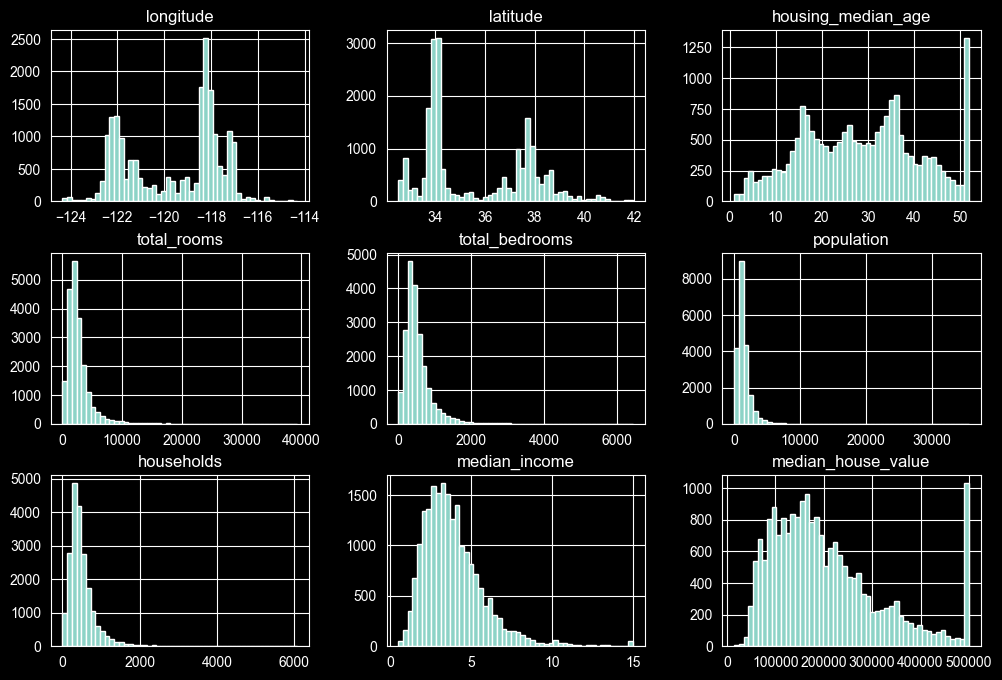

In [7]:
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(12,8))
plt.show()

# 6. 创建测试集
1. 方式1：根据datasets长度做索引打乱以进行一次性划分，采用np.random.permutation()
2. 方式2：根据index采用crc32方式计算hash值，用以划分数据集
3. 方式3：利用数据特性构建hash值，用以划分数据集
4. 方式4：利用Scikit-learn提供的train_test_split()函数
5. 方式5：利用Scikit-learn提供的model_selection包中的拆分函数，如StratifiedShuffleSplit()函数（分层混乱拆分）

## 1. 方式1：根据datasets长度做索引打乱以进行一次性划分，采用np.random.permutation()

In [2]:
import numpy as np

# 把数据随机打乱，然后按比例切分为训练集与测试集
# data：通常是一个 pandas.DataFrame
# test_ratio：测试集占比（例如 0.2 表示 20% 为测试集）

# 设置随机种子
np.random.seed(42)

def shuffle_and_split_data(data, test_ratio):
    # 断言：测试集比例必须在 (0, 1) 之间
    assert 0 < test_ratio < 1, "test_ratio must be between 0 and 1 (exclusive)."

    # np.random.permutation(n)：生成 0 ~ n-1 的一个随机排列数组
    shuffled_indices = np.random.permutation(len(data)) # len(data)：数据的行数（样本数）
    test_set_size = int(len(data) * test_ratio) # 计算测试集大小

    # 断言：测试集大小必须大于 0 且小于总样本数
    assert 0 < test_set_size < len(data), "Invalid test set size computed."

    test_indices = shuffled_indices[:test_set_size] # 取打乱后的前 test_set_size 个索引作为测试集索引。
    train_indices = shuffled_indices[test_set_size:] # 训练集取剩余的部分

    # data.iloc[...]：按行位置索引取数据（支持用整数数组）返回两个 DataFrame：
    return data.iloc[train_indices], data.iloc[test_indices]

* 注意：
    * 如果未加`np.random.seed(42)`运行上述程序会产生问题：**将会生成不同的测试集**
    * 解决方案（也存在问题）：
       1. 在第一次运行时保存测试集，然后在后续运行中加载该测试集
      2. 在调用`np.random.permutation()`之前设计随机数生成器的种子，以始终生成相同的混淆索引
    * 上述两种解决方案在下次获取更新的数据集时会失效，最好的解决方案如下：
        * 使用每个实例的标识符来决定它是否应该进入测试集（假设实例有唯一且不可变的标识符）
            * 例如：
                * **例如,你可以计算每个实例标识符的哈希值,如果哈希值低于或等于最大哈希值的20%,则将该实例放入测试集中。这可确保测试集在多次运行中保持一致,即使你刷新数据集也是如此。新的测试集将包含20%的新实例,但不会包含之前训练集中的任何实例。**
                * “给每一条数据一个固定不变的编号，然后用这个编号算出一个“固定的随机数”。
                * 我们规定：如果这个数落在前 20% 的范围内，就把这条数据放进测试集，否则放进训练集。
                * 因为同一个编号每次算出来的结果都一样，所以不管你运行程序多少次，数据都会被分到同样的集合里。
                * 即使后来数据变多了，旧数据的位置也不会变，只是新加的数据中大约有 20% 会被分到测试集里。”

In [3]:
# 使用shuffle_and_split_data函数
train_set, test_set = shuffle_and_split_data(data=housing, test_ratio=0.2)
print("Train set size: ", len(train_set))
print("Test set size: ", len(test_set))
train_set.head()

Train set size:  16512
Test set size:  4128


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
14196,-117.22,32.75,34.0,6001.0,1111.0,2654.0,1072.0,4.5878,291000.0,NEAR OCEAN
8267,-117.03,32.69,10.0,901.0,163.0,698.0,167.0,4.6648,156100.0,NEAR OCEAN
17445,-122.27,37.74,28.0,6909.0,1554.0,2974.0,1484.0,3.6875,353900.0,NEAR BAY
14265,-121.82,37.25,25.0,4021.0,634.0,2178.0,650.0,5.1663,241200.0,<1H OCEAN
2271,-115.98,33.32,8.0,240.0,46.0,63.0,24.0,1.4688,53800.0,INLAND


## 2. 方式2：根据index采用crc32方式计算hash值，用以划分数据集
* 利用每个实例的标识符的哈希值来划分训练集

### `in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))`
#### 使用 `apply` 判断样本是否属于测试集


#### 功能说明

该代码用于**逐条判断数据集中每个样本是否应被划分到测试集**，并生成对应的布尔标记结果。

---

#### 执行过程说明

* `ids`：数据集中样本的唯一标识符（ID）列
* `apply()`：对该列中的**每一个 ID**执行一次给定函数
* `lambda id_`：表示当前正在处理的单个样本 ID
* `is_id_in_test_set(id_, test_ratio)`：

  * 根据 ID 的哈希值和测试集比例判断该样本是否进入测试集
  * 返回 `True` 或 `False`

---

#### 返回结果

* `in_test_set` 是一个布尔型 `Series`

  * `True`：该样本被划分到测试集
  * `False`：该样本被划分到训练集

---

#### 使用意义

通过对每个样本 ID 进行独立、确定性的判断，可以保证：

* 多次运行程序时数据划分结果一致
* 数据集更新时，原有训练集样本不会被划入测试集

该方法常用于避免数据泄漏，提升模型评估的可靠性。

---

* 补充：
    * lambda 是 “临时用一下的小函数”，写法是：`lambda 参数: 返回值`

---

### `return data.loc[~in_test_set], data.loc[in_test_set]`
#### 使用布尔索引划分训练集与测试集


##### 1. `in_test_set` 的含义

* 一个与 `data` 行数一致的布尔型 Series
* `True` 表示该样本属于测试集
* `False` 表示该样本属于训练集

---

##### 2. `data.loc[条件]` 的作用

* 根据给定条件筛选行
* 条件为 `True` 的行会被保留下来

---

##### 3. `~in_test_set` 的作用

* `~` 表示逻辑取反
* 将 `True` 变为 `False`，`False` 变为 `True`

---

##### 4. 划分逻辑

* `data.loc[in_test_set]` → 测试集
* `data.loc[~in_test_set]` → 训练集

---

##### 5. 返回结果

* 返回两个 DataFrame：

  * 第一个是训练集
  * 第二个是测试集

---

##### 6. 一句话总结

通过布尔索引，可以根据每一行的判断结果，
将原始数据稳定、无重叠地划分为训练集和测试集。

---

* 补充
    * 一列 = Series，多列 = DataFrame

In [4]:
from zlib import crc32 # 导入 CRC32 哈希函数，crc32 是一种快速、稳定、确定性的哈希函数，非加密哈希，但非常适合做“数据划分”

# 判断“一个 ID 是否应该进测试集”
# crc32(...)：把 ID 映射到一个固定的 32 位哈希值
def is_id_in_test_set(identifier, test_ratio): # identifier：样本的唯一标识符；test_ratio：测试集比例
    return crc32(np.int64(identifier)) < test_ratio * 2**32

# 用哈希规则划分整个数据集
def split_data_with_id_hash(data, test_ratio, id_column): # data：pandas DataFrame；id_column：作为唯一标识符的列名
    # print("type_data" + str(type(data))) # type_data<class 'pandas.core.frame.DataFrame'>
    ids = data[id_column] # 取出 ID 列（Series）
    # print("type_ids" + str(type(ids))) # type_ids<class 'pandas.core.series.Series'>
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    # 等价于下述代码
    # in_test_set = []
    #
    # for id_ in ids:
    #     result = is_id_in_test_set(id_, test_ratio)
    #     in_test_set.append(result)
    return data.loc[~in_test_set], data.loc[in_test_set]

* reset_index() 会**把原来的行索引变成一列**并生成一个新的默认索引

In [5]:
housing_with_id = housing.reset_index()
# print(housing_with_id) # 可以看到索引变为一列
train_set, test_set = split_data_with_id_hash(housing_with_id, test_ratio=0.2, id_column="index")
print(train_set.head())

   index  longitude  latitude  housing_median_age  total_rooms  \
0      0    -122.23     37.88                41.0        880.0   
1      1    -122.22     37.86                21.0       7099.0   
3      3    -122.25     37.85                52.0       1274.0   
4      4    -122.25     37.85                52.0       1627.0   
6      6    -122.25     37.84                52.0       2535.0   

   total_bedrooms  population  households  median_income  median_house_value  \
0           129.0       322.0       126.0         8.3252            452600.0   
1          1106.0      2401.0      1138.0         8.3014            358500.0   
3           235.0       558.0       219.0         5.6431            341300.0   
4           280.0       565.0       259.0         3.8462            342200.0   
6           489.0      1094.0       514.0         3.6591            299200.0   

  ocean_proximity  
0        NEAR BAY  
1        NEAR BAY  
3        NEAR BAY  
4        NEAR BAY  
6        NEAR BAY  


## 使用 `index` 作为 ID 的注意事项

### 1. 当前做法的本质
- 通过 `reset_index()`，将 DataFrame 原有的行索引显式变成了一列（`index`）
- 该列可以作为样本的“唯一标识符”用于哈希划分训练集与测试集
- 这种做法**在教学或演示场景中是可行的**

---

### 2. 使用 `index` 作为 ID 的前提条件
当且仅当满足以下条件时，使用 `index` 作为 ID 才是安全的：
- 数据只允许 **追加（append）**
- 不允许在中间插入新数据
- 不允许重新排序、重建索引或过滤后再 `reset_index()`

否则：
- 原有样本的 index 会发生变化
- 哈希结果改变
- 训练集 / 测试集归属发生变化
- 可能引发 **数据泄漏**

---

### 3. 在中间插入新数据会导致的问题
- 插入操作会整体推移后续样本的 index
- 旧样本的 ID 改变
- 原本在训练集的样本可能进入测试集（反之亦然）
- 破坏基于 ID 的稳定划分假设

---

### 4. 工程级推荐做法
- **不要使用 DataFrame 的 index 作为真实 ID**
- 优先使用：
  - 业务层面的唯一 ID（如 `user_id`, `house_id`）
- 若无业务 ID，可构造稳定 ID：
  - 由不随数据顺序变化的字段生成（如经纬度组合）

---

### 5. 一句话总结
> 用 `index` 当 ID 只在“只追加、不重排”的严格约束下成立；
> 在真实项目中，应使用来源于样本自身的稳定 ID，
> 才能保证训练集与测试集划分长期一致且不发生数据泄漏。

### 6. 例如，用一个地区的经纬度来组成一个ID，如下：

## 3. 方式3：利用数据特性构建hash值，用以划分数据集

In [39]:
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
# print(housing_with_id)
train_set, test_set = split_data_with_id_hash(housing_with_id, test_ratio=0.2, id_column="id")
print(train_set.values)

[[0 -122.23 37.88 ... 452600.0 'NEAR BAY' -122192.12]
 [1 -122.22 37.86 ... 358500.0 'NEAR BAY' -122182.14]
 [2 -122.24 37.85 ... 352100.0 'NEAR BAY' -122202.15]
 ...
 [20637 -121.22 39.43 ... 92300.0 'INLAND' -121180.57]
 [20638 -121.32 39.43 ... 84700.0 'INLAND' -121280.57]
 [20639 -121.24 39.37 ... 89400.0 'INLAND' -121200.63]]


## 方式4：利用Scikit-learn提供的train_test_split()函数

`train_test_split()`源码

```
def train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None,
):
    # 1. 参数校验（略）

    n_samples = len(arrays[0])

    # 2. 计算测试集大小
    if test_size is None:
        test_size = 0.25
    n_test = int(n_samples * test_size)

    # 3. 生成索引
    if shuffle:
        rng = np.random.RandomState(random_state)
        indices = rng.permutation(n_samples)
    else:
        indices = np.arange(n_samples)

    # 4. 划分索引
    test_indices = indices[:n_test]
    train_indices = indices[n_test:]

    # 5. 根据索引切分所有输入数组
    result = []
    for array in arrays:
        result.extend([
            array[train_indices],
            array[test_indices]
        ])

    return tuple(result)

```

它与`shuffle_and_split_data()`函数的功能差不多，多了一个random_state参数，它允许设置随机生成器种子，并且`train_test_split()`的本质不是“切数据”，而是“先切索引，再用同一套索引切所有数据”。

In [29]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

* 纯随机的采样会大概率引入采样偏差的风险，故应采用**分层采样**：
    * 定义：将总体分为称为曾的同质子组，并从每个层中抽取正确数量的实例以保证测试集能代表总体。
* 假如housing data中的收入中位数（median_income）对于预测房价中位数是一个非常重要的参数，那么在进行分层采样前，应使用pd.cut()函数创建一个收入类别属性，有5个类别（标记从1到5）；类别1的范围从0到1.5（即低于15000美元），类别2的范围从1.5到3，以此类推。


income_cat
1     822
2    6581
3    7236
4    3639
5    2362
Name: count, dtype: int64


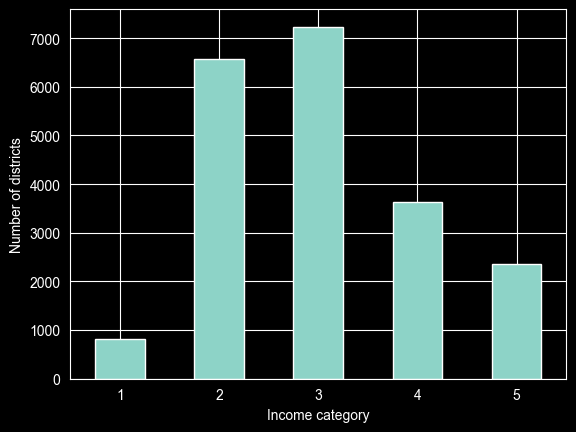

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 把连续的收入变量离散化， 最终得到的新列，是一个类别型变量（Categorical）housing["income_cat"]。
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0, 1.5, 3.0, 4.5, 6., np.inf], # 把收入划分为不同区间，np.inf 表示正无穷
                               labels=[1, 2, 3, 4, 5]) # 给每个区间一个离散标签

print(housing["income_cat"].value_counts().sort_index())

# 1.统计每个收入类别出现的次数（.value_counts()）；2.按类别顺序排序（.sort_index()）；3.绘制柱状图，rot=0：x 轴标签不旋转（保持竖直）
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [9]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3


## 5. 方式5：利用Scikit-learn提供的model_selection包中的拆分函数，如StratifiedShuffleSplit()函数（分层混乱拆分）

### sklearn.model_selection包
Scikit-Learn在sklearn.model_selection包中提供了很多拆分类，它们实现了各种策略将数据集拆分为训练集和测试集，每个拆分器都有一个split()方法，该方法返回对相同数据的不同训练/测试拆分的迭代器。

#### `StratifiedShuffleSplit()`
* `StratifiedShuffleSplit()` 是一个：“在随机打乱数据的同时，严格保持类别比例不变的切分器”。
* 核心API如下：
```python
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(
    n_splits=10, # 要生成多少次“独立的分层随机切分”
    test_size=0.2,
    random_state=42
)
```
* 注意：StratifiedShuffleSplit 是“索引生成器”，而不是“数据切分器”。
* 分析其中的n_splits参数：

---

### 1) `n_splits` 到底是什么？一句话先说清

> **`n_splits` 表示：要“重复生成多少次”分层随机切分（train/test 划分）。**
> 每一次切分都会：

* 随机打乱（shuffle）
* 按类别比例分层（stratified）
* 产生一组新的 `(train_indices, test_indices)`

它不是“把数据切成 n 份”，也不是“n 折交叉验证”的那个折数概念。

---

### 2) 为什么需要 `n_splits`？通俗解释

想象你在做实验：

* 你把数据随机划分一次，训练/测试得到一个分数（例如准确率 0.86）
* 但你知道：**随机切分一次的结果可能碰巧好或碰巧差**
* 为了更可靠，你希望：

> “我多随机切几次，每次都保持类别比例一致，然后看模型平均表现。”

这就是 `n_splits` 的意义：

* `n_splits=1`：只切一次（最常见）
* `n_splits=10`：切 10 次（10 组不同的 train/test），得到 10 个评估分数，再求平均

---

### 3) `n_splits` 和 test_size 的关系（直观）

* `test_size=0.2` 决定：**每次切分测试集占 20%**
* `n_splits=5` 决定：**这样的切分重复做 5 次**

注意：
这些切分之间**不是互斥**的（不是把数据分成 5 个互不重叠的测试集）。
不同切分里，某个样本可能这次在测试集、下次在训练集。

---

## 4) 用一个具体例子说明整个 `StratifiedShuffleSplit`

### 例子数据：10 个样本，两个类别 A/B

我们用最简单的分类分层例子：

* 总样本：10
* 类别 A：6 个（60%）
* 类别 B：4 个（40%）

把样本用索引表示：

* A 类：`[0,1,2,3,4,5]`
* B 类：`[6,7,8,9]`

---

### 设置切分器

```python
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=2, test_size=0.2, random_state=42)
```

含义：

* `test_size=0.2` → 每次测试集取 20%：10×0.2=2 个样本
* `n_splits=2` → 生成 2 次不同的切分
* `stratified` → 测试集里也要保持 A:B = 60%:40%

---

### 关键：每次测试集要取多少 A、多少 B？

测试集总共 2 个样本：

* A 类比例 60% → 2×0.6=1.2 ≈ 1 个
* B 类比例 40% → 2×0.4=0.8 ≈ 1 个

所以**每次测试集必须包含：**

* A：1 个
* B：1 个

训练集自然就是剩下的：

* A：5 个
* B：3 个

这就是“分层”的具体含义：**每次切分都维持比例**。

---

### 第 1 次切分（split #1）

假设随机结果选到：

* 测试集：A 选 `[2]`，B 选 `[8]`
* 测试集索引：`[2, 8]`

那么训练集就是剩下的：

* 训练集索引：`[0,1,3,4,5,6,7,9]`

你会发现：

* 测试集：A=1，B=1（比例保持）
* 训练集：A=5，B=3（比例也差不多保持）

---

### 第 2 次切分（split #2）

因为 `n_splits=2`，还会再来一次随机分层切分。

假设第二次选到：

* 测试集：A 选 `[5]`，B 选 `[6]`
* 测试集索引：`[5, 6]`
* 训练集索引：`[0,1,2,3,4,7,8,9]`

同样：

* 测试集依然 A=1，B=1

---

## 5) 这就是 `n_splits` 的“输出形式”

当你运行：

```python
for train_idx, test_idx in sss.split(X, y):
    print(train_idx, test_idx)
```

它会输出 **n_splits 次**：

* 第一次：一组 train/test 索引
* 第二次：另一组 train/test 索引
* …直到 n_splits 次结束

---

## 6) 最常见用法：`n_splits=1`（你只想切一次）

很多教材用：

```python
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
```

原因是：

* 你只需要一个“可靠的分层训练/测试集”
* 不需要重复很多次

---

## 7) 一句话总结 `n_splits`

> **`n_splits` 不是“分成几份”，而是“重复切分几次”。**
> 每次都会生成一套新的、保持类别比例的 train/test 索引。

---

* splitter.split(X, y)：

    * X = housing（只用于提供样本数量）

    * y = housing["income_cat"]（分层依据）

---

```
strat_splits = [
  [train_set_1, test_set_1],
  [train_set_2, test_set_2],
  ...
  [train_set_10, test_set_10]
]
```

In [20]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

strat_splits = [] # 用来保存每一次切分得到的：[训练集 DataFrame, 测试集 DataFrame]
for train_index, test_index in splitter.split(housing, housing["income_cat"]):
    strat_train_set_n = housing.iloc[train_index] # .iloc[...]：按行位置索引取数据
    strat_test_set_n = housing.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])
    print(train_index, test_index)
print("--------------------")
print(strat_splits[1])

[13096 14973  3785 ... 19301 19121 19888] [ 3905 16821  2900 ... 16634  9779  3455]
[12898  9367 19304 ...  9356  7535  3261] [11734  3016 19907 ...  5264  9811   993]
[ 1108 13041 14023 ... 14230  3997 15875] [15389  7193 13314 ... 10546 11151 10640]
[20581  1857  9942 ...  1532  1406  3859] [14190  9837 17881 ... 14140 16175  1598]
[ 9346 12457 16765 ...  9305 20087  3928] [16578  3358  1369 ... 14702   495 10955]
[15191 13992 15445 ... 18711 19772  1096] [ 2256 17567  9009 ... 20309  9003 16106]
[ 6408 17079  9105 ...  9124 17358  3215] [ 1980 10719  7725 ... 18893 15186 10560]
[14758 14246  1868 ...   763 12526 16847] [ 1678  1268  8056 ... 11087 20139  1135]
[ 8147 16627  6352 ... 12324 18267 12790] [19338  9719 20036 ...  2553  8616 19450]
[19887  9051  2502 ...  4591  3656  9393] [ 3804 17282 12044 ...  3225 10033  4082]
--------------------
[       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
12898    -117.95     33.84                32.0       1378.0

In [27]:
# 1. 只使用第一个拆分结果
strat_train_set, strat_test_set = strat_splits[0]

print(strat_train_set.info())
print("--------------------------------------------")
print(housing["income_cat"].value_counts() / len(housing))
print("--------------------------------------------")
print(strat_train_set["income_cat"].value_counts() / len(strat_train_set))

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16512 non-null  float64 
 1   latitude            16512 non-null  float64 
 2   housing_median_age  16512 non-null  float64 
 3   total_rooms         16512 non-null  float64 
 4   total_bedrooms      16344 non-null  float64 
 5   population          16512 non-null  float64 
 6   households          16512 non-null  float64 
 7   median_income       16512 non-null  float64 
 8   median_house_value  16512 non-null  float64 
 9   ocean_proximity     16512 non-null  object  
 10  income_cat          16512 non-null  category
dtypes: category(1), float64(9), object(1)
memory usage: 1.4+ MB
None
--------------------------------------------
income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64
------------------

* 由于分层采样相当普遍，故可以采用更简洁的方法可以使用带有stratify参数的train_test_split()函数来获得单个拆分

```
def train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None,
):
```

In [30]:
strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

print(strat_train_set["income_cat"].value_counts() / len(strat_train_set))

income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64


* 拆分完数据集后删除income_cat列，恢复原始数据集

In [31]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True) # axis=1：表示按列删除,inplace=True表示：直接在原 DataFrame 上修改,不返回新对象

print(strat_train_set)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096    -122.42     37.80                52.0       3321.0          1115.0   
14973    -118.38     34.14                40.0       1965.0           354.0   
3785     -121.98     38.36                33.0       1083.0           217.0   
14689    -117.11     33.75                17.0       4174.0           851.0   
20507    -118.15     33.77                36.0       4366.0          1211.0   
...          ...       ...                 ...          ...             ...   
14207    -118.40     33.86                41.0       2237.0           597.0   
13105    -119.31     36.32                23.0       2945.0           592.0   
19301    -117.06     32.59                13.0       3920.0           775.0   
19121    -118.40     34.06                37.0       3781.0           873.0   
19888    -122.41     37.66                44.0        431.0           195.0   

       population  households  median_income  media

# 7. 探索和可视化数据

* 在划分完测试集后，应探索训练集，如果训练集很大应进行采样

* 由于要实验完整训练集的各种变换，因此需要制作一份原始副本，以便之后可以恢复。

In [34]:
# 备份训练集
housing = strat_train_set.copy()
print(housing.info())

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.4+ MB
None
<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  

## 7.1 可视化数据
* 创建所有地区的散点图来可视化数据

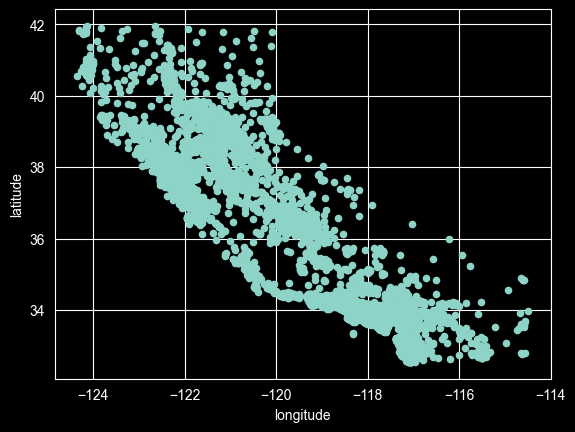

In [37]:
housing.plot(kind="scatter", x="longitude", y = "latitude", grid=True) # kind 用来指定“用什么类型的图来画数据”。散点图（Scatter Plot）
plt.show()

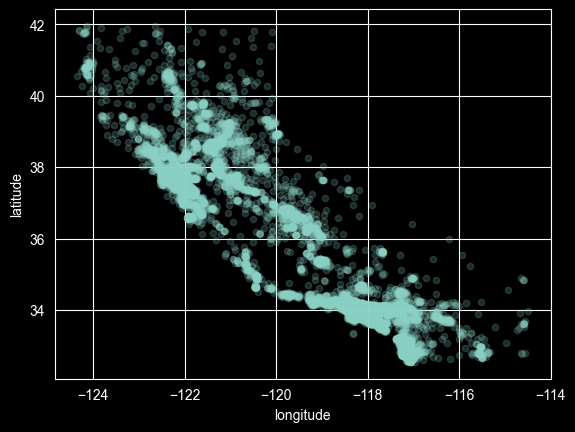

In [38]:
housing.plot(kind="scatter", x="longitude", y = "latitude", grid=True, alpha=0.2) # alpha 表示“透明度”,alpha = 1.0 → 完全不透明
plt.show()

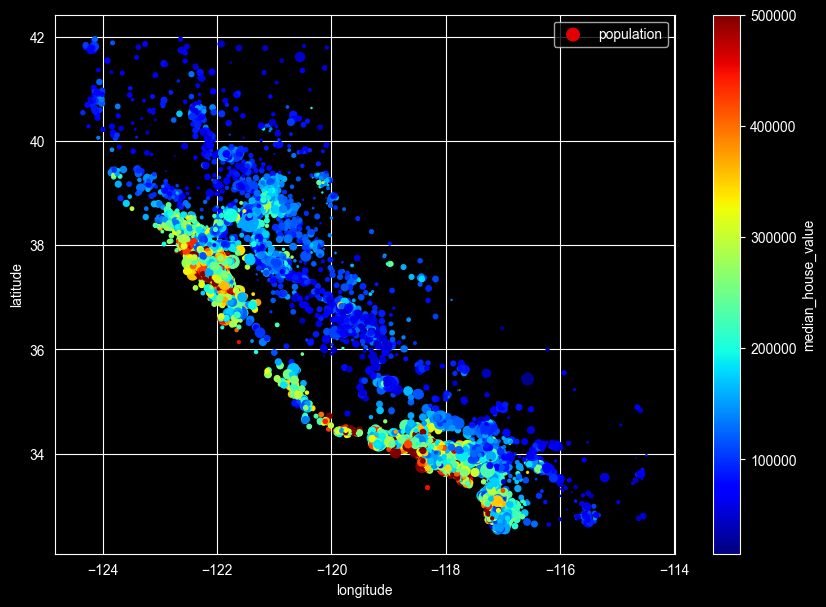

In [44]:
housing.plot(kind="scatter", x="longitude", y = "latitude", grid=True,
             s=housing["population"] / 100, label="population", # s：scatter中**点的面积**大小,用 人口数 / 100 来缩放, 给“点大小”这个含义一个标签
             c="housing_median_age", cmap="jet", colorbar=True, # c 表示 用哪一列来映射颜色，房价越高 → 颜色越偏向色带的高端；cmap：颜色映射方案（colormap）；"jet" 是一种经典的连续色带：蓝 → 绿 → 黄 → 红；colorbar=True，在图右侧显示 颜色条，颜色 ↔ 数值（房价）的对应关系
             legend=True, sharex=False, figsize=(10, 7)) # legend=True：显示图例；sharex=False：不与其他子图共享 x 轴
plt.show()

* 上图说明：红色为昂贵，蓝色为便宜，圆圈越大代表地区人口越多
* 观察上图，可知道房价与地理位置和人口密度高度相关。

* 对前一幅插图做一个美化版本，在背景中添加了加利福尼亚州图像，采用更美观的标签名称，并去除了网格线。
# 地理数据可视化（可复用模板笔记）

---

### 2️⃣ 通用保存图片函数（强烈推荐）

```python
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)
```

**优点**

* 统一管理输出图片
* 默认 300 dpi，适合论文与报告
* 可在整个项目中反复复用

---

## 三、地图背景准备（一次写好，长期可用）

### 3️⃣ 下载并缓存地图图片

```python
import urllib.request

filename = "map.png"
if not (IMAGES_PATH / filename).is_file():
    url = "https://example.com/map.png"
    urllib.request.urlretrieve(url, IMAGES_PATH / filename)
```

**原则**

* 本地已有 → 不再下载
* 保证代码可重复运行

---

## 四、为“展示”重命名列（不污染原数据）

```python
data_vis = data.rename(columns={
    "longitude": "Longitude",
    "latitude": "Latitude",
    "population": "Population",
    "target": "Target value"
})
```

**经验原则**

* 原始数据用于建模
* 重命名版本仅用于可视化 / 展示

---

## 五、多变量散点图（核心模板）

```python
data_vis.plot(
    kind="scatter",
    x="Longitude",
    y="Latitude",
    s=data_vis["Population"] / 100,
    label="Population",
    c="Target value",
    cmap="jet",
    colorbar=True,
    legend=True,
    figsize=(10, 7),
    alpha=0.3
)
```

### 视觉编码规则速记

| 视觉元素  | 表示信息      |
| ----- | --------- |
| x / y | 地理位置      |
| s     | 数值规模（如人口） |
| c     | 目标变量（如房价） |
| alpha | 密度感知      |

---

## 六、叠加地图背景（关键技巧）

### 6️⃣ 读取地图并对齐坐标系

```python
import matplotlib.pyplot as plt

map_img = plt.imread(IMAGES_PATH / filename)

axis = x_min, x_max, y_min, y_max
plt.axis(axis)
plt.imshow(map_img, extent=axis)
```

**关键点**

* `extent` 必须与经纬度范围一致
* 否则地图与散点无法对齐

---

## 七、保存并显示最终图像

```python
save_fig("final_geo_visualization")
plt.show()
```

---

## 八、完整流程速览（背下来就能用）

```text
准备路径
 → 定义保存函数
 → 下载地图
 → 重命名展示列
 → scatter 多变量绘图
 → imshow 叠加地图
 → 保存 + show
```

---

## 九、实战经验总结（非常重要）

1. **地图背景只负责“视觉”，不参与计算**
2. **点大小必须缩放（/100、/1000）**
3. **大量点一定要用 alpha**
4. **可视化列名 ≠ 建模列名**
5. **保存函数一定要统一管理**

---

## 十、一句话终极总结

> 这套模板用于在真实地图坐标系中，将多维数值信息压缩到一张高质量散点图中，是数据探索与结果展示中极具表达力的一种可视化方式。


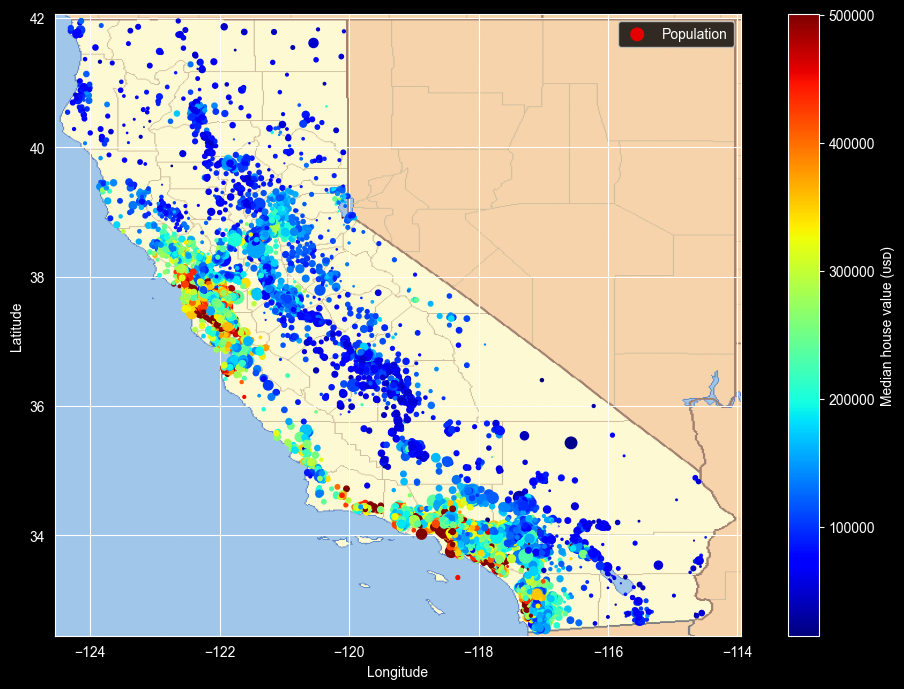

In [52]:
# extra code – this cell generates the first figure in the chapter

# Download the California image
# 图片保存路径
IMAGES_PATH = Path() / "images" / "end_to_end_project"
IMAGES_PATH.mkdir(parents=True, exist_ok=True) # 如果父目录不存在 → 一并创建；如果已存在 → 不报错

# 一个通用的“保存图片函数”
# fig_id：文件名（不含扩展名）；tight_layout：是否自动压缩布局；fig_extension：图片格式（默认 png）；resolution：分辨率（dpi，300 适合论文/印刷）
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}" # 拼出完整保存路径
    if tight_layout:
        plt.tight_layout() # 自动调整子图间距，避免标签被裁剪
    plt.savefig(path, format=fig_extension, dpi=resolution) # 保存当前 Matplotlib 图像

# 下载加州地图背景图片
filename = "california.png"
if not (IMAGES_PATH / filename).is_file():
    homl3_root = "https://github.com/ageron/handson-ml3/raw/main/"
    url = homl3_root + "images/end_to_end_project/" + filename
    print("Downloading", filename)
    urllib.request.urlretrieve(url, IMAGES_PATH / filename)

# 数据列重命名
housing_renamed = housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
housing_renamed.plot(
             kind="scatter", x="Longitude", y="Latitude",
             s=housing_renamed["Population"] / 100, label="Population",
             c="Median house value (ᴜsᴅ)", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))

# 叠加加州地图背景
california_img = plt.imread(IMAGES_PATH / filename) # 读取地图图片
axis = -124.55, -113.95, 32.45, 42.05 # 设置坐标轴范围，x_min, x_max, y_min, y_max
plt.axis(axis)
plt.imshow(california_img, extent=axis) # extent=axis：把图片“拉伸”到经纬度坐标范围

# 保存并显示最终图像
save_fig("california_housing_prices_plot")
plt.show()

## 7.2 寻找相关性
### 方法1：如果数据不太大，则可以使用`corr()`方法计算出每对属性之间的标准相关系数（也称皮尔逊r）

````markdown
## Pandas `corr()` 方法笔记

### 1. 方法作用
`corr()` 用于计算 **DataFrame 中数值型特征两两之间的相关系数**，
常用于探索性数据分析（EDA）阶段，帮助判断变量之间的线性关系强弱。

---

### 2. 基本用法

```python
corr_matrix = df.corr()
````

* 返回一个 **相关系数矩阵（DataFrame）**
* 行和列均为数值型特征名
* 非数值型列会被自动忽略

---

### 3. 默认相关系数类型

```python
df.corr(method="pearson")
```

* 默认使用 **皮尔逊相关系数（Pearson Correlation）**
* 适合衡量两个连续变量之间的**线性关系**

相关系数取值范围：

| 值  | 含义    |
| -- | ----- |
| +1 | 完全正相关 |
| 0  | 无线性相关 |
| -1 | 完全负相关 |

---

### 4. 常见 `method` 参数

```python
df.corr(method="pearson")   # 默认，线性相关
df.corr(method="spearman")  # 基于秩的相关，适合单调关系
df.corr(method="kendall")   # 非参数相关，适合小样本
```

| 方法       | 适用场景      |
| -------- | --------- |
| Pearson  | 连续变量、线性关系 |
| Spearman | 非线性但单调关系  |
| Kendall  | 小样本、稳健分析  |

---

### 5. 典型使用场景

#### （1）查看某一目标变量的相关性

```python
df.corr()["target"].sort_values(ascending=False)
```

* 快速找出与目标变量关系最强的特征

---

#### （2）特征选择参考

* 高相关特征 → 可能是重要特征
* 低相关特征 → 可能信息量较小（需结合业务判断）

---

### 6. 输出结果的特点

* 对角线元素恒为 `1.0`（变量与自身的相关性）
* 矩阵对称
* 只反映 **线性相关性**

---

### 7. 注意事项（非常重要）

1. **相关性 ≠ 因果关系**
2. `corr()` 无法捕捉非线性复杂关系
3. 强相关特征之间可能存在多重共线性
4. 类别型特征需先编码（如 One-Hot）才能参与计算

---

### 8. 一句话总结

> `corr()` 是一种快速、直观的线性相关性分析工具，
> 常用于建模前的特征探索与筛选，但应结合可视化和业务理解综合判断。

---

* corr()默认采用皮尔逊r(协方差÷(标准差×标准差))计算相关系数r，故只能处理数值型数据，当有下述报错时：“could not convert string to float: 'NEAR BAY'”说明DataFrame中包含了非数值型列，在该环境下它无法自动忽略该值，应手动处理

In [51]:
# 先计算数据集中各数值特征之间的相关系数矩阵，
# 再查看“房价中位数”与其他特征的相关程度，并按强弱排序。
corr_matrix = housing.corr(numeric_only=True) # 显式告诉 corr() 只用数值列

corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

### 方法2：使用Pandas的scatter_matrix()函数，它可以将每个数值属性与其他每个数值属性进行对比。

````markdown
## Pandas `scatter_matrix()` 方法笔记

### 1. 方法作用
`scatter_matrix()` 用于 **同时可视化多个数值型特征之间的两两关系**，
是探索性数据分析（EDA）中常用的快速检查工具。

它可以帮助你：
- 发现特征之间的相关关系（线性 / 非线性）
- 观察单变量分布形态
- 识别异常值（outliers）

---

### 2. 基本用法

```python
from pandas.plotting import scatter_matrix

scatter_matrix(df, figsize=(12, 8))
````

* `df`：`pandas.DataFrame`
* 只会使用 **数值型列**
* 字符串 / 类别列会被自动忽略

---

### 3. 输出图像结构说明

生成的是一个 **N × N 的矩阵图**（N 为数值特征个数）：

* **对角线**：

  * 每个特征自身的分布
  * 默认显示直方图（Histogram）
* **非对角线**：

  * 两个不同特征之间的散点图（Scatter Plot）

示意结构：

```
        A        B        C
A     hist     scatter   scatter
B   scatter     hist     scatter
C   scatter   scatter     hist
```

---

### 4. 常用参数

| 参数         | 作用                            |
| ---------- | ----------------------------- |
| `figsize`  | 控制整体图像大小                      |
| `alpha`    | 设置散点透明度，避免重叠                  |
| `diagonal` | 控制对角线显示方式（`"hist"` / `"kde"`） |
| `marker`   | 设置散点样式                        |

示例：

```python
scatter_matrix(
    df,
    figsize=(12, 8),
    alpha=0.2,
    diagonal="kde"
)
```

---

### 5. 典型使用场景

#### （1）相关性探索

* 点云呈斜线 → 可能存在强相关
* 点云呈圆团 → 相关性弱

#### （2）发现非线性关系

* 即使 `corr()` 值很小
* 也可能在散点图中看到曲线或分段趋势

#### （3）检查异常值

* 孤立点、极端点一眼可见

#### （4）查看分布形态

* 偏态
* 长尾
* 是否需要对数变换

---

### 6. 与 `corr()` 的对比

| 方法                 | 输出   | 优点    | 局限   |
| ------------------ | ---- | ----- | ---- |
| `corr()`           | 数值矩阵 | 快、定量  | 仅线性  |
| `scatter_matrix()` | 图像矩阵 | 直观、全面 | 不给数值 |

**推荐组合使用**：

```text
corr() → 定量筛选
scatter_matrix() → 形态确认
```

---

### 7. 使用建议（经验总结）

1. 特征较多时，**先筛选关键列**
2. 数据量大时，降低 `alpha`
3. 结果只用于探索，不直接作为结论
4. 建模前使用，避免“盲目选特征”

---

### 8. 一句话总结

> `scatter_matrix()` 是一种高效的多变量可视化工具，
> 能在建模前快速揭示特征之间的关系结构，是 EDA 阶段的重要手段。



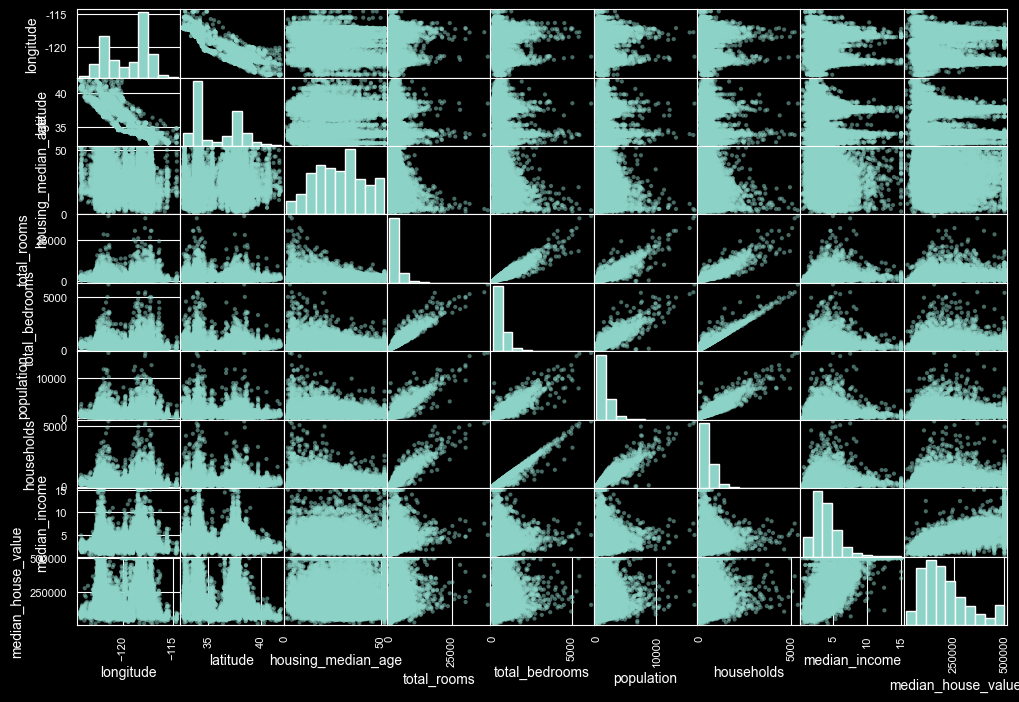

In [56]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing, figsize=(12, 8))
plt.show()

* 根据scatter_matrix的结果可以看出，与房价中位数相关的最正相关的是收入中位数（呈正斜线），放大该散点图

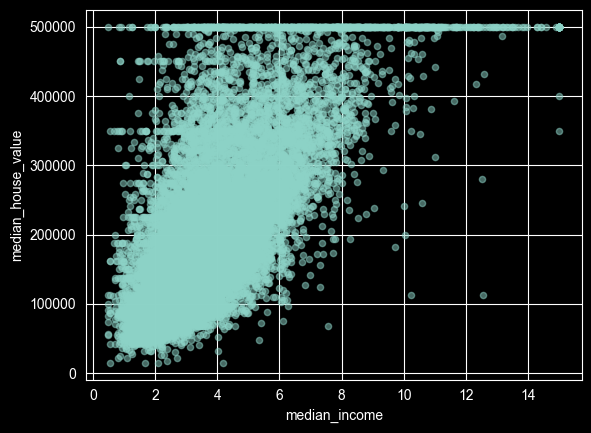

In [65]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.5, grid=True) # alpha 表示“透明度”
plt.show()

## 7.3 实验不同属性组合

In [66]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"] # 每户房间数
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing['total_rooms'] # 卧室比例
housing["people_per_house"] = housing["population"] / housing["households"] # 每户人口数

print(housing.head())

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096    -122.42     37.80                52.0       3321.0          1115.0   
14973    -118.38     34.14                40.0       1965.0           354.0   
3785     -121.98     38.36                33.0       1083.0           217.0   
14689    -117.11     33.75                17.0       4174.0           851.0   
20507    -118.15     33.77                36.0       4366.0          1211.0   

       population  households  median_income  median_house_value  \
13096      1576.0      1034.0         2.0987            458300.0   
14973       666.0       357.0         6.0876            483800.0   
3785        562.0       203.0         2.4330            101700.0   
14689      1845.0       780.0         2.2618             96100.0   
20507      1912.0      1172.0         3.5292            361800.0   

      ocean_proximity  rooms_per_house  bedrooms_ratio  people_per_house  
13096        NEAR BAY         3.211799   

In [68]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

## 8. 为机器学习算法准备数据
* 为准备数据编写一个函数，原因如下：
    * 可以在任何数据集上轻松地重现这些转换（如下次获得新的数据集时）
    * 可以逐步构建一个可以在未来项目中重复使用的转换函数库
    * 可以在实时系统中使用这些函数来转换新的数据，再将其提供给算法
    * 可以轻松尝试各种转换并查看哪种转换组合效果最好

In [76]:
housing = strat_train_set.drop("median_house_value", axis=1) # drop() 用来从 DataFrame 或 Series 中“删除指定的行或列”。注意：drop()创建数据的副本并且不会影响strat_train_set。
housing_label = strat_train_set["median_house_value"].copy()

# print(housing)
print(housing_label)

13096    458300.0
14973    483800.0
3785     101700.0
14689     96100.0
20507    361800.0
           ...   
14207    500001.0
13105     88800.0
19301    148800.0
19121    500001.0
19888    233300.0
Name: median_house_value, Length: 16512, dtype: float64


## 8.1 清洗数据

* 1. 当有属性有缺省值时，可考虑3种解决方法：
    * 1. 去掉相应的地区
        * `.dropna()`: 用于删除包含缺失值（NaN）的行或列。
            * 如：`housing.dropna(subset=["total_bedrooms"], inplace=True)`会将删除 housing 中所有 total_bedrooms 为缺失值（NaN）的行，并直接在原 DataFrame 上生效。inplace=True表示直接修改 housing 本身，不返回新的DataFrame
    * 2. 去掉整个属性
            * `.drop("total_bedrooms", axis=1)`直接删除这一列
    * 3. 将缺省值设置为某个值（零、均值、中位数等）。这称为归责（破坏性最小，适用）
            * `.fillna()`用于“填补缺失值（NaN）”
            * 如`housing.fillna({"total_bedrooms": housing["total_bedrooms"].median()}, inplace=True) `取中值填补


In [77]:
housing.info() # 可观察到total_bedrooms有一些缺省值

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.8+ MB


* 使用Scikit-Learn类SimpleImputer：将存储每个特征的中位数值，不仅可以在训练集上估算缺失值，而且可以在验证集、测试集和任何提供给模型的新数据上估算缺失值。
* 仅能根据数值属性来计算中位数
* SimpleImputer会简单计算每个属性的中位数并将结果存储在它的statistics_实例变量中
* 还有KNNImputer：将每个缺省值替换为该特征的k近邻的平均值。该距离和基于所有可用的特征
* 还有IterativeImputer：为每个特征训练一个回归模型，以根据所有其他可用特征预测缺省值。然后，它会根据更新后的数据再次训练模型，并多次重复该过程，在每次迭代中改进模型和替换值。

In [96]:
# 使用SimpleImputer填补缺失值
from sklearn.impute import SimpleImputer

# 创建一个SimpleImputer实例
imputer = SimpleImputer(strategy="median") # 也可以是最频繁的值(strategy="most_frequent")；也可以是常数值（strategy="constant", fill_value=...）

# 创建仅包含数值属性的数据副本，排除文本属性ocean_proximity
housing_num = housing.select_dtypes(include=[np.number])
# print(housing_num.info())

# 使用fit()将imputer实例拟合到训练数据中
imputer.fit(housing_num)

print(imputer.statistics_)
print(housing_num.median().values)
print(imputer.feature_names_in_)

# 将imputer学习到的中位数替换缺失值来转换数据集
X = imputer.transform(housing_num)

X.shape


[-118.51     34.26     29.     2125.      434.     1167.      408.
    3.5385]
[-118.51     34.26     29.     2125.      434.     1167.      408.
    3.5385]
['longitude' 'latitude' 'housing_median_age' 'total_rooms'
 'total_bedrooms' 'population' 'households' 'median_income']


(16512, 8)

* `imputer.fit(housing_num)`说明
    * 对 housing_num 的每一列，逐列执行：
        * 找出非缺失值
        * 计算该列的 中位数
        * 把这个中位数存下来
* `transform()`说明：
    * 对 housing_num 的每一列，逐列执行：
        * 找到缺失值（NaN）
        * 查找该列对应的中位数（来自 imputer.statistics_）
        * 用这个中位数 替换 NaN
        * 非缺失值保持不变
    * 返回的是一个 NumPy ndarray，而不是 DataFrame
* 也可以直接用`fit_transform()`方法，它所做的就是先`fit()`再`transform()`

In [98]:
# 将转换器所输出的Numpy数组（有时是Scipy稀疏矩阵）x包装在DataFrame中，并从housing_num中恢复列名和索引
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)

print(housing_tr.info())

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
dtypes: float64(8)
memory usage: 1.6 MB
None


* 目前只处理了数字属性，但数据集中可能还包含文本属性。在该数据集中，只有一个：ocean_proximity属性

In [109]:
# 查看该属性
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

print(type(housing_cat))

<class 'pandas.core.frame.DataFrame'>


In [110]:
# 大多数机器学习算法更喜欢处理数字，所以将这些类别属性从文本转换为数字
# 使用Scikit-Learn中的OrdinalEncoder类
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

print(housing_cat_encoded) # 返回的是Numpy数组

# 使用categories_实例变量获取类别列表
# ordinal_encoder.categories_

# 再转换为DataFrame
housing_cat_encoded_tr = pd.DataFrame(housing_cat_encoded, columns=housing_cat.columns,
                                      index=housing_cat.index)

print(housing_cat_encoded_tr.head(8))


[[3.]
 [0.]
 [1.]
 ...
 [4.]
 [0.]
 [4.]]
       ocean_proximity
13096              3.0
14973              0.0
3785               1.0
14689              1.0
20507              4.0
1286               1.0
18078              0.0
4396               3.0
